# Segmentation + skills library building

## Initialization

In [1]:
import shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score
import datetime as dt

# from scipy import signal
from scipy.interpolate import make_splrep

# from scipy.interpolate import UnivariateSpline
import os
from pathlib import Path
from tqdm.auto import tqdm
from pprint import pprint
import ruptures as rpt
from ruptures.metrics import precision_recall, hausdorff, randindex
import distancia

In [2]:
from segmentation_utils import (
    # extract_eef_data_from_rosbag,
    get_ground_truth_segmentation,
    # get_bagfiles_from_json,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
from LfD_Library.MP_Library import gen_traj, MP_Library
from LfD_Library.sim_metrics import *
from ElasticMaps.elmap_EM import ElmapEM

In [4]:
USETEX = bool(shutil.which("latex"))
mpl.rcParams["text.usetex"] = USETEX
if USETEX:
    mpl.rcParams["font.family"] = ["serif"]
else:
    mpl.rcParams["font.family"] = ["sans-serif"]
    mpl.rcParams["font.sans-serif"] = [
        "Fira Sans",
        "Computer Modern Sans Serif",
        "DejaVu Sans",
        "Verdana",
        "Arial",
        "Helvetica",
    ]

In [5]:
# Make transparent background plot
TRANSP_BACK_PLOT = True
# TRANSP_BACK_PLOT = False

In [6]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

## Data files

In [7]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path(".") / "data"
data_path_root.exists()

True

In [8]:
ground_truth_segm_file = Path(".") / "segm_ground_truth.json"
ground_truth_segm_file.exists()

True

In [9]:
# bagfiles = get_bagfiles_from_json(ground_truth_segm_file=ground_truth_segm_file)
# bagfiles

In [10]:
filenum = 0
# bagfile = bagfiles[filenum]
# bagfile

In [11]:
gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
    ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
)
pprint(gt_segm_dict)

{'hdf5': 'long-task-1.h5',
 'segments': {'close-drawer': {'end': 1769723276, 'ini': 1769723270},
              'grasping': [{'end': 1769723226, 'ini': 1769723222},
                           {'end': 1769723239, 'ini': 1769723237},
                           {'end': 1769723253, 'ini': 1769723251},
                           {'end': 1769723270, 'ini': 1769723267},
                           {'end': 1769723296, 'ini': 1769723288}],
              'open-drawer': {'end': 1769723231, 'ini': 1769723226},
              'placing': [{'end': 1769723245, 'ini': 1769723239},
                          {'end': 1769723258, 'ini': 1769723253}],
              'pouring': {'end': 1769723309, 'ini': 1769723296},
              'reaching': [{'end': 1769723222, 'ini': 1769723215},
                           {'end': 1769723237, 'ini': 1769723234},
                           {'end': 1769723251, 'ini': 1769723248},
                           {'end': 1769723267, 'ini': 1769723262},
                           {'end

In [12]:
hdf5_path = data_path_root / hdf5_file
video_path = data_path_root / video_file

## Preprocessing

In [13]:
joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)

['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


In [14]:
# traj = extract_eef_data_from_rosbag(bagfile)
traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
traj

,x,y,z,timestamp,gripper
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01
...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01


In [15]:
# df = traj.diff().mean().timestamp.total_seconds()
# df

In [16]:
# downsampling = 10

In [17]:
# freq = 1 / (df * downsampling)
# freq

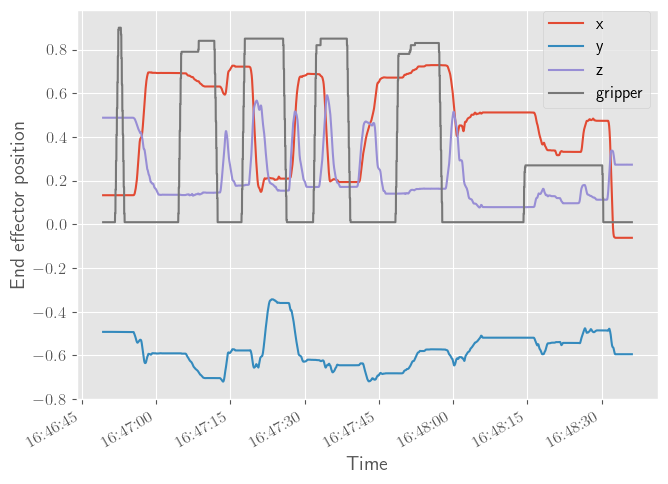

In [18]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(traj.timestamp, traj.x, label="x")  # , color=cmap[0])
    ax.plot(traj.timestamp, traj.y, label="y")  # , color=cmap[1])
    ax.plot(traj.timestamp, traj.z, label="z")  # , color=cmap[2])
    ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Ground truth segmentation

In [19]:
# gt_segm_dict = get_ground_truth_segmentation(
#     ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
# )
# pprint(gt_segm_dict)

### Adding more features: objects moving

In [20]:
nsegments = 0
obj_labels = []
for segm_key, segm_val in gt_segm_dict["segments"].items():
    if isinstance(segm_val, list):
        nsegments += len(segm_val)
        for jdx, _ in enumerate(segm_val):
            obj_labels.append(f"{segm_key}-{jdx + 1}")
    elif isinstance(segm_val, dict):
        nsegments += 1
        obj_labels.append(segm_key)
    else:
        raise ValueError("Unexpected value in ground truth JSON file")
nsegments, obj_labels

(20,
 ['reaching-1',
  'reaching-2',
  'reaching-3',
  'reaching-4',
  'reaching-5',
  'open-drawer',
  'grasping-1',
  'grasping-2',
  'grasping-3',
  'grasping-4',
  'grasping-5',
  'placing-1',
  'placing-2',
  'releasing-1',
  'releasing-2',
  'releasing-3',
  'releasing-4',
  'releasing-5',
  'close-drawer',
  'pouring'])

In [21]:
objects = np.zeros((traj.shape[0], nsegments))
objects.shape

(53137, 20)

In [22]:
col_i = 0
for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
    sect_dict_current = gt_segm_dict["segments"][sect_key]
    if isinstance(sect_dict_current, list):
        for sect_j, sect_cur in enumerate(sect_dict_current):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            print(col_i)
            objects[xs.index, col_i] = np.ones_like(xs)
            col_i += 1

    elif isinstance(sect_dict_current, dict):
        xs = traj.timestamp[
            (
                traj.timestamp
                > pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
            & (
                traj.timestamp
                < pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["end"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
        ]
        print(col_i)
        objects[xs.index, col_i] = np.ones_like(xs)
        col_i += 1
    else:
        raise ValueError("Unexpected value in ground truth JSON file")

objects

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(53137, 20))

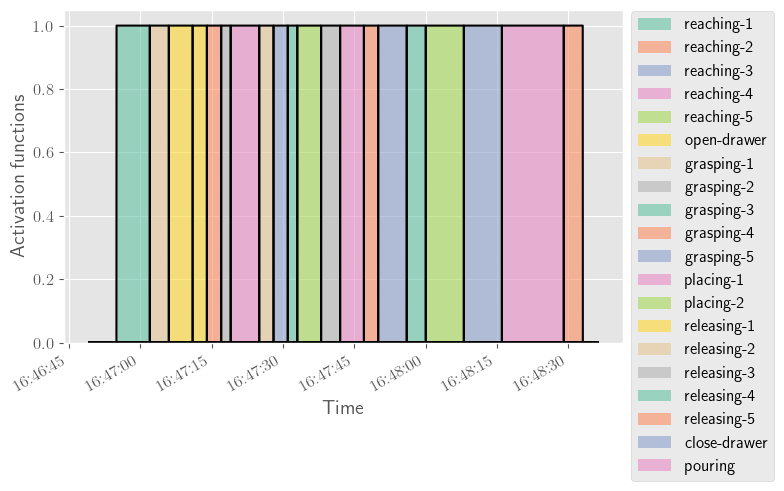

In [23]:
with plt.style.context("ggplot_perso.mplstyle"):
    cmap = mpl.colormaps.get("Set2").colors
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx in range(objects.shape[1]):
        ax.plot(
            traj.timestamp,
            objects[:, idx],
            # label=obj_labels[idx],
            color="k",
            # linewidth=1.5,
        )
    ax.stackplot(
        traj.timestamp,
        objects.T,
        labels=obj_labels,
        alpha=0.6,
        colors=cmap,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Activation functions")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [24]:
for idx in range(objects.shape[1]):
    traj[obj_labels[idx]] = objects[:, idx]
traj

,x,y,z,timestamp,gripper,reaching-1,reaching-2,reaching-3,reaching-4,reaching-5,...,grasping-5,placing-1,placing-2,releasing-1,releasing-2,releasing-3,releasing-4,releasing-5,close-drawer,pouring
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# def add_more_features(ground_truth_segm_file, bagfile, traj):
#     # Get the ground truth data for the BAG file
#     gt_segm_dict = get_ground_truth_segmentation(
#         ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
#     )

#     # Initialize the matrix
#     objects = np.zeros((traj.shape[0], len(gt_segm_dict["HigherLevel"].keys())))

#     # Set to ones for each object when it's moving
#     for sect_i, sect_key in enumerate(gt_segm_dict["HigherLevel"].keys()):
#         sect_dict_current = gt_segm_dict["HigherLevel"][sect_key]
#         xs = traj.timestamp[
#             (
#                 traj.timestamp
#                 > pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["ini"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#             & (
#                 traj.timestamp
#                 < pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["end"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#         ]
#         objects[xs.index, sect_i] = np.ones_like(xs)

#     # Merge with the original DataFrame
#     for idx in range(objects.shape[1]):
#         traj[list(gt_segm_dict["HigherLevel"].keys())[idx]] = objects[:, idx]
#     return traj

### Plot segments

/tmp/ipykernel_361866/3711827594.py:104: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


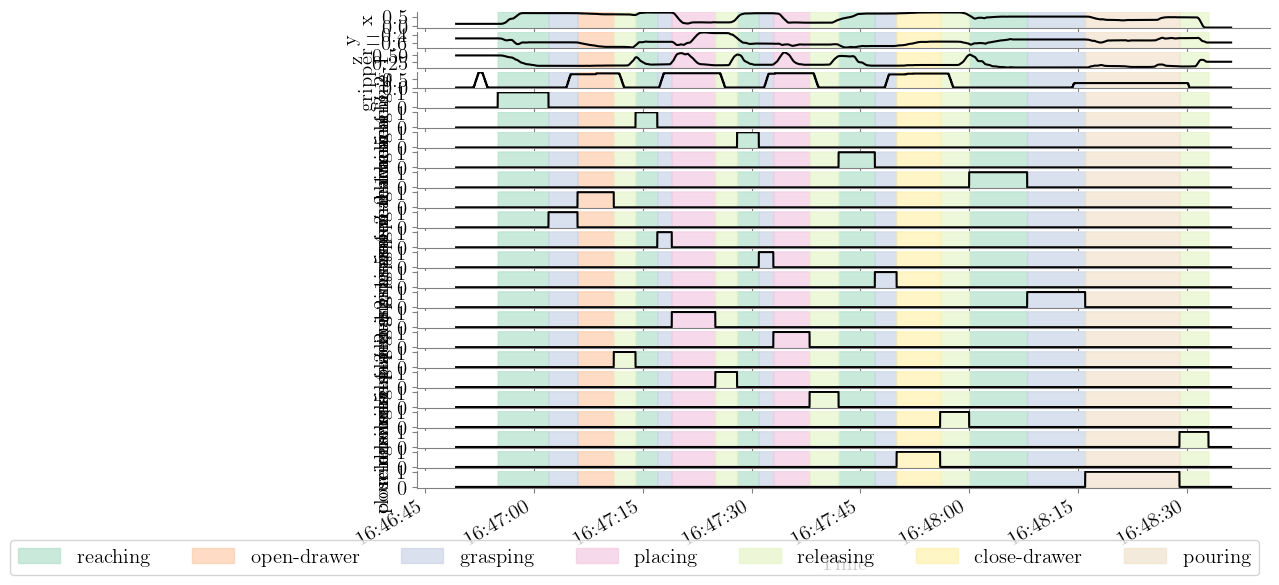

In [26]:
df_labels = list(traj.drop(columns=["timestamp"]).keys())
fig, axes = plt.subplots(
    nrows=len(df_labels), ncols=1, sharex=True, sharey=False, figsize=(11, 7)
)
cmap = mpl.colormaps.get("Pastel2").colors
labels_fontsize = 15
for idx, ax in enumerate(axes):
    for item in (
        [ax.title, ax.xaxis.label, ax.yaxis.label]
        + ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        item.set_fontsize(labels_fontsize)

    ax.plot(traj.timestamp, traj[df_labels[idx]], "k")
    ax.set_ylabel(df_labels[idx])
    ax.spines[["right", "top"]].set_visible(False)

    y_low = traj[df_labels[idx]].min()
    y_high = traj[df_labels[idx]].max()
    y_range = np.abs(y_high - y_low) / 2
    y_top = y_high + 0.1 * y_range
    y_bottom = y_low - 0.1 * y_range
    ax.set_ylim(bottom=y_bottom, top=y_top)
    ax.tick_params(color="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("gray")

    for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
        skill_current = gt_segm_dict["segments"][sect_key]
        if isinstance(skill_current, list):
            for skill_i, skill_val in enumerate(skill_current):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]  # - dt.timedelta(hours=5)
                if skill_i == 0:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                        label=sect_key,
                    )
                else:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                    )
        elif isinstance(skill_current, dict):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]  # - dt.timedelta(hours=5)
            ax.fill_between(
                x=xs,
                y1=y_bottom,
                y2=y_top,
                color=cmap[sect_i],
                alpha=0.7,
                # transform=ax.get_xaxis_transform(),
                label=sect_key,
            )
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

axes[-1].set_xlabel("Time")
# fig.suptitle("Ground truth segmentation", fontsize=14)
fig.autofmt_xdate()
fig.tight_layout()
axes[-1].legend(bbox_to_anchor=(1, -2.5), ncol=nsegments, fontsize=labels_fontsize)
if TRANSP_BACK_PLOT:
    fig.patch.set_alpha(0)
    fig.patch.set_facecolor("white")

plt.show()

## Segmentation

### Hyperparameters

In [27]:
# downsampling_factor = 200
resample_num = 2**8
# resample_num = 2**7
print(f"Resampling to {resample_num} data points")
# smoothing = 0.1

Resampling to 256 data points


In [28]:
# what_segments = "HigherLevel"
# # what_segments = "LowerLevel"

labels = gt_segm_dict["segments"].keys()
labels

dict_keys(['reaching', 'open-drawer', 'grasping', 'placing', 'releasing', 'close-drawer', 'pouring'])

### Preprocessing

In [29]:
X = traj.drop(columns=["timestamp"])
X

,x,y,z,gripper,reaching-1,reaching-2,reaching-3,reaching-4,reaching-5,open-drawer,...,grasping-5,placing-1,placing-2,releasing-1,releasing-2,releasing-3,releasing-4,releasing-5,close-drawer,pouring
0,0.133347,-0.491981,0.488070,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.133354,-0.491975,0.488080,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133358,-0.491972,0.488044,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.133351,-0.491997,0.488007,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133328,-0.491981,0.488071,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53133,-0.061486,-0.594203,0.273203,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53134,-0.061480,-0.594227,0.273175,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53135,-0.061488,-0.594235,0.273185,0.01,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
def smooth_traj(traj, nb_points=256, smoothing_factor=0):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col], s=smoothing_factor)(
                        new_index
                    ),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col], s=smoothing_factor)(
                new_index
            )
    return traj_smooth

In [31]:
# # X_down = signal.decimate(x=X_filtered, q=downsampling_factor, axis=0)
# X_down = signal.resample(x=X, num=resample_num, axis=0)
# X_down = smooth_traj(traj=X, nb_points=resample_num, smoothing=smoothing)
X_down = smooth_traj(traj=X, nb_points=resample_num)
X_down.shape

(256, 24)

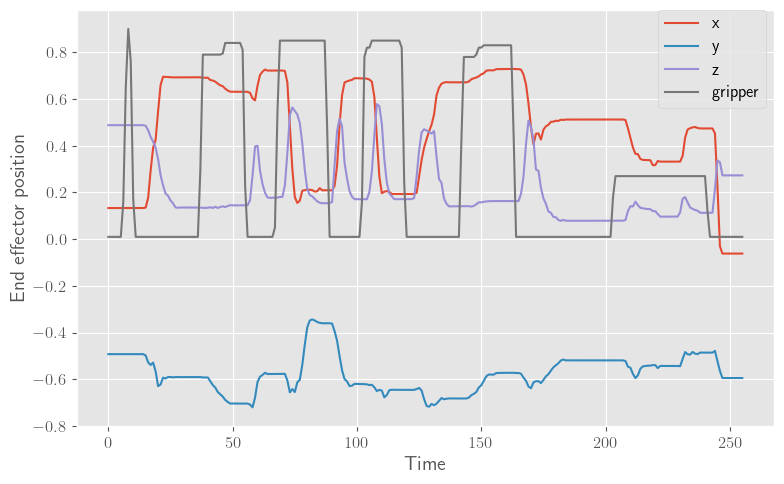

In [32]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(X_down.index, X_down.x, label="x")  # , color=cmap[0])
    ax.plot(X_down.index, X_down.y, label="y")  # , color=cmap[1])
    ax.plot(X_down.index, X_down.z, label="z")  # , color=cmap[2])
    ax.plot(X_down.index, X_down.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    # fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [33]:
minmaxscaler = MinMaxScaler(feature_range=(0, 1))
X_down_scaled = minmaxscaler.fit_transform(X_down)
X_down_scaled

array([[2.46604807e-001, 6.04815557e-001, 8.19985491e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003],
       [2.46619969e-001, 6.04837214e-001, 8.19987706e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003],
       [2.46598603e-001, 6.04822760e-001, 8.19935497e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003],
       ...,
       [6.10680407e-005, 3.33132549e-001, 3.89892417e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003],
       [5.34433755e-005, 3.33155138e-001, 3.89864766e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003],
       [5.46715339e-005, 3.33152735e-001, 3.89845601e-001, ...,
        6.51481325e-119, 3.10390655e-018, 6.85834174e-003]],
      shape=(256, 24))

### Change Point Dectection

In [34]:
# if what_segments == "HigherLevel":
#     # Higher level change points
#     # cpd_segm_penalty = 125
#     cpd_segm_penalty = 9
#     true_chg_pts_iso = [segm["end"] for segm in gt_segm_dict[what_segments].values()]

cpd_segm_penalty = 2
# cpd_segm_penalty = 5
true_chg_pts_iso = []
for idx, skill in enumerate(gt_segm_dict["segments"].values()):
    if isinstance(skill, list):
        for segm in skill:
            if idx == 0:
                true_chg_pts_iso.append(segm["ini"])
            true_chg_pts_iso.append(segm["end"])
    elif isinstance(skill, dict):
        if idx == 0:
            true_chg_pts_iso.append(skill["ini"])
        true_chg_pts_iso.append(skill["end"])

    else:
        raise ValueError("Unexpected value in ground truth JSON file")

true_chg_pts_iso = sorted(list(set(sorted(true_chg_pts_iso))))
true_chg_pts_iso

[1769723215,
 1769723222,
 1769723226,
 1769723231,
 1769723234,
 1769723237,
 1769723239,
 1769723245,
 1769723248,
 1769723251,
 1769723253,
 1769723258,
 1769723262,
 1769723267,
 1769723270,
 1769723276,
 1769723280,
 1769723288,
 1769723296,
 1769723309,
 1769723313]

In [35]:
true_chg_pts = np.empty_like(true_chg_pts_iso) * np.nan
true_chg_pts

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [36]:
for idx in range(len(true_chg_pts)):
    true_chg_pts[idx] = traj[
        traj.timestamp
        >= pd.Timestamp(
            dt.datetime.fromtimestamp(
                true_chg_pts_iso[idx]
            ),  # - dt.timedelta(hours=1),
            tz="EST",
        )
    ].index[0]
# true_chg_pts = [int(item) for item in sorted(list(set(true_chg_pts)))]
true_chg_pts

array([ 2862.,  6351.,  8344., 10840., 12333., 13832., 14832., 17829.,
       19327., 20820., 21818., 24299., 26280., 28757., 30245., 33222.,
       35211., 39182., 43133., 49592., 51581.])

In [37]:
true_chg_pts_resampled = [
    round(item * resample_num / X.index.stop) for item in true_chg_pts
]
true_chg_pts_resampled = sorted(list(set(true_chg_pts_resampled)))
true_chg_pts_resampled

[14,
 31,
 40,
 52,
 59,
 67,
 71,
 86,
 93,
 100,
 105,
 117,
 127,
 139,
 146,
 160,
 170,
 189,
 208,
 239,
 249]

In [38]:
if true_chg_pts_resampled[-1] != resample_num:
    true_chg_pts_resampled.append(resample_num)
true_chg_pts_resampled

[14,
 31,
 40,
 52,
 59,
 67,
 71,
 86,
 93,
 100,
 105,
 117,
 127,
 139,
 146,
 160,
 170,
 189,
 208,
 239,
 249,
 256]

In [39]:
# detection
algo = rpt.Pelt(model="rbf", min_size=2, jump=2).fit(X_down_scaled)
# algo = rpt.KernelCPD(kernel="rbf").fit(X_down_scaled)
# algo = rpt.KernelCPD(kernel="cosine").fit(X_scaled)
computed_chg_pts = algo.predict(pen=cpd_segm_penalty)
print(computed_chg_pts)

[14, 30, 40, 54, 60, 68, 72, 86, 92, 100, 106, 118, 126, 138, 146, 160, 170, 188, 208, 238, 248, 256]


In [40]:
precision, recall = precision_recall(true_chg_pts_resampled, computed_chg_pts)
precision, recall

(0.7142857142857143, 0.7142857142857143)

In [41]:
hausdorff(true_chg_pts_resampled, computed_chg_pts)

np.float64(2.0)

In [42]:
randindex(true_chg_pts_resampled, computed_chg_pts)

0.9915441176470589

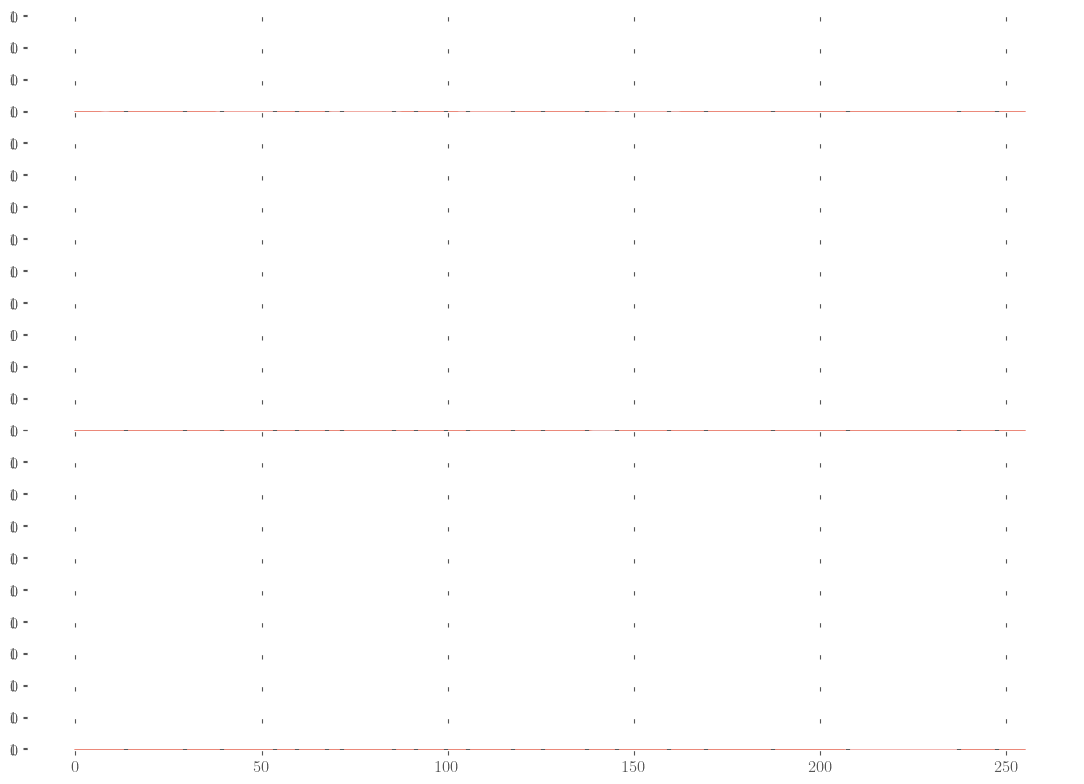

In [43]:
# display
with plt.style.context("ggplot_perso.mplstyle"):
    # rpt.display(minmaxscaler.inverse_transform(X_down_scaled), bkps, result)
    rpt.display(
        signal=X_down_scaled,
        true_chg_pts=true_chg_pts_resampled,
        computed_chg_pts=computed_chg_pts,
        figsize=(11, 8),
    )
    plt.show()

In [44]:
# ### To be removed
# computed_chg_pts = true_chg_pts_resampled
# ### To be removed

assert len(computed_chg_pts) == len(true_chg_pts_resampled), (
    "CPD method didn't find the right number of segments"
    f"\nTrue changepoint number: {len(true_chg_pts_resampled)}"
    f"\nComputed changepoint number: {len(computed_chg_pts)}"
)

In [45]:
# chg_pts_all = np.concat([[0], computed_chg_pts])
chg_pts_all = computed_chg_pts[:-1]
chg_pts_all

[14,
 30,
 40,
 54,
 60,
 68,
 72,
 86,
 92,
 100,
 106,
 118,
 126,
 138,
 146,
 160,
 170,
 188,
 208,
 238,
 248]

## Build skills library

In [46]:
colsids2keep = [0, 1, 2, 3]

In [47]:
### Resample segments to the same length
chg_pts_conv_ori = np.array(
    [int(round(item * len(traj) / resample_num)) for item in chg_pts_all]
)
chg_pts_conv_ori

array([ 2906,  6227,  8303, 11209, 12454, 14115, 14945, 17851, 19096,
       20757, 22002, 24493, 26153, 28644, 30305, 33211, 35286, 39022,
       43174, 49401, 51476])

In [48]:
similarity_threshold = 0.8
# similarity_threshold = 0.2

In [49]:
# demos = []
# for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
#     # ts_segm = np.arange(start=0, stop=chg_pts_all[seg_i + 1] - chg_pts_all[seg_i])
#     pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], 0:4]
#     # demos.append(np.concat((ts_segm[:, np.newaxis], pos_segm), axis=1))
#     print(pos_segm.shape)
#     demos.append(pos_segm)

In [50]:
def resample_array(array, nb_points=256, smoothing_factor=1e-3):
    ori_index = np.arange(array.shape[0])
    new_index = np.linspace(start=0, stop=array.shape[0], num=nb_points)
    arr_resampled = np.ones((nb_points, array.shape[1])) * np.nan
    for colidx, _ in enumerate(range(array.shape[1])):
        arr_resampled[:, colidx] = make_splrep(
            ori_index, array[:, colidx], s=smoothing_factor
        )(new_index)
    return arr_resampled

In [51]:
# def resample_array(traj, n=200):
#     """Resample & smooth a trajectory.
#     Use a univariate spline for each dimension"""
#     n_pts, n_dims = np.shape(traj)
#     # new_traj = np.zeros((n, n_dims+1))
#     new_traj = np.zeros((n, n_dims))
#     t = np.linspace(0, 1, n_pts)
#     tt = np.linspace(0, 1, n)
#     # new_traj[:, 0] = tt
#     for i in range(n_dims):
#         sp = UnivariateSpline(t, traj[:, i].flatten(), s=1e-3)
#         # sp.set_smoothing_factor(1e-3)
#         smooth_resampled = sp(tt)
#         # new_traj[:, i+1] = smooth_resampled
#         new_traj[:, i] = smooth_resampled
#     return new_traj

In [52]:
demos = []
for seg_i, seg_v in enumerate(chg_pts_conv_ori[:-1]):
    pos_segm = X.iloc[
        chg_pts_conv_ori[seg_i] : chg_pts_conv_ori[seg_i + 1], colsids2keep  # 0:4
    ].to_numpy()
    pos_segm_resampled = resample_array(array=pos_segm, nb_points=resample_num)
    # pos_segm_resampled = resample_array(traj=pos_segm, n=resample_num)
    print(
        f"Original shape: {pos_segm.shape} - resampled shape: {pos_segm_resampled.shape}"
    )
    demos.append(pos_segm_resampled)

Original shape: (3321, 4) - resampled shape: (256, 4)
Original shape: (2076, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (830, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (1245, 4) - resampled shape: (256, 4)
Original shape: (2491, 4) - resampled shape: (256, 4)
Original shape: (1660, 4) - resampled shape: (256, 4)
Original shape: (2491, 4) - resampled shape: (256, 4)
Original shape: (1661, 4) - resampled shape: (256, 4)
Original shape: (2906, 4) - resampled shape: (256, 4)
Original shape: (2075, 4) - resampled shape: (256, 4)
Original shape: (3736, 4) - resampled shape: (256, 4)
Original shape: (4152, 4) - resampled shape: (256, 4)
Original shape: (6227, 4) - r

In [53]:
test_metric = distancia.Frechet().calculate
# test_metric = PCA_metric
# test_metric = SimilarityTs_metric

Class not matched, new class: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.780
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.780
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.832
Class not matched, new class: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.375
Class: 'Skill_1' - Similarity: 0.839
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.379
Class: 'Skill_1' - Similarity: 0.858
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.598
Class: 'Skill_1' - Similarity: 1.014
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.889
Class: 'Skill_1' - Similarity: 0.547
Class matched: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.189
Class: 'Skill_1' - Similarity: 0.888
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.139
Class: 'Skill_1' - Similarity: 0.861
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.299
Class: 'Skill_1' - Similarity: 0.910
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.886
Class: 'Skill_1' - Similarity

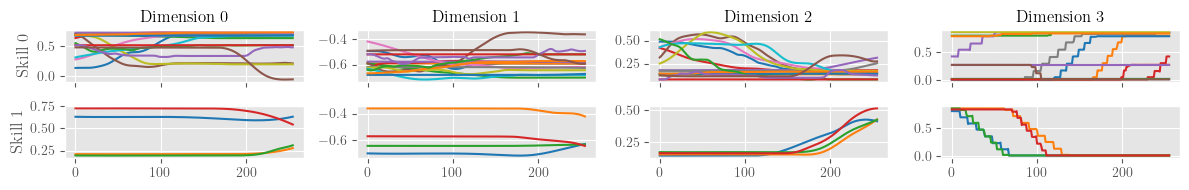

In [54]:
lib_path = Path("lib.h5")
if lib_path.exists():
    lib_path.unlink()
# skills_lib = MP_Library(metric=COS_metric, threshold=similarity_threshold, debug=True)
# skills_lib = MP_Library(metric=SSE_metric, threshold=similarity_threshold, debug=True)
skills_lib = MP_Library(metric=test_metric, threshold=similarity_threshold, debug=True)
# skills_lib = MP_Library(metric=Pearson_metric, threshold=similarity_threshold, debug=True)
for demo_i in demos:
    skills_lib.add_primitive(demo_i)
skills_lib.display()
skills_lib.plot_separate()
skills_lib.save_h5(lib_path)

In [55]:
# pprint(skills_lib.library)

## LfD learning & stitching

In [56]:
execution_time = 1.0

In [57]:
idx = 0
ts_segm = np.arange(chg_pts_all[idx], chg_pts_all[idx + 1])
ts_segm

array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [58]:
pos_segm = X_down_scaled[chg_pts_all[idx] : chg_pts_all[idx + 1], colsids2keep]
pos_segm.shape

(16, 4)

In [59]:
n_dims = pos_segm.shape[1]

In [60]:
n_nodes = 35
stretch = 0.005
bend = 0.005
weighting = "uniform"
downsampling = "distance"

In [61]:
lfd_out_txt = list(Path(".").glob("LfD_segm_*.txt"))
lfd_out_txt

[PosixPath('LfD_segm_0.txt'),
 PosixPath('LfD_segm_1.txt'),
 PosixPath('LfD_segm_2.txt'),
 PosixPath('LfD_segm_3.txt'),
 PosixPath('LfD_segm_4.txt'),
 PosixPath('LfD_segm_5.txt'),
 PosixPath('LfD_segm_6.txt'),
 PosixPath('LfD_segm_7.txt'),
 PosixPath('LfD_segm_8.txt'),
 PosixPath('LfD_segm_9.txt'),
 PosixPath('LfD_segm_10.txt'),
 PosixPath('LfD_segm_11.txt'),
 PosixPath('LfD_segm_12.txt'),
 PosixPath('LfD_segm_13.txt'),
 PosixPath('LfD_segm_14.txt'),
 PosixPath('LfD_segm_15.txt'),
 PosixPath('LfD_segm_16.txt'),
 PosixPath('LfD_segm_17.txt'),
 PosixPath('LfD_segm_18.txt'),
 PosixPath('LfD_segm_19.txt')]

In [62]:
if len(list(lfd_out_txt)) > 0:
    for item in list(lfd_out_txt):
        print(item)
        item.unlink()

LfD_segm_0.txt
LfD_segm_1.txt
LfD_segm_2.txt
LfD_segm_3.txt
LfD_segm_4.txt
LfD_segm_5.txt
LfD_segm_6.txt
LfD_segm_7.txt
LfD_segm_8.txt
LfD_segm_9.txt
LfD_segm_10.txt
LfD_segm_11.txt
LfD_segm_12.txt
LfD_segm_13.txt
LfD_segm_14.txt
LfD_segm_15.txt
LfD_segm_16.txt
LfD_segm_17.txt
LfD_segm_18.txt
LfD_segm_19.txt


Constraints:
[[14.     0.133 -0.492  0.488  0.01 ]
 [30.     0.693 -0.59   0.136  0.01 ]]
Start of learned trajectory: [14.017  0.134 -0.492  0.488  0.01 ]
End of learned trajectory: [29.993  0.693 -0.59   0.136  0.01 ]
Constraints:
[[30.     0.693 -0.59   0.136  0.01 ]
 [40.     0.691 -0.592  0.134  0.79 ]]
Start of learned trajectory: [30.018  0.693 -0.59   0.136  0.01 ]
End of learned trajectory: [39.994  0.691 -0.592  0.134  0.789]
Constraints:
[[40.     0.691 -0.592  0.134  0.79 ]
 [54.     0.631 -0.703  0.145  0.811]]
Start of learned trajectory: [40.014  0.691 -0.592  0.134  0.79 ]
End of learned trajectory: [53.993  0.631 -0.703  0.145  0.812]
Constraints:
[[54.     0.631 -0.703  0.145  0.811]
 [60.     0.657 -0.611  0.4    0.01 ]]
Start of learned trajectory: [54.013  0.631 -0.703  0.145  0.806]
End of learned trajectory: [59.988  0.655 -0.613  0.399  0.01 ]
Constraints:
[[60.     0.657 -0.611  0.4    0.01 ]
 [68.     0.722 -0.577  0.178  0.54 ]]
Start of learned trajectory: [

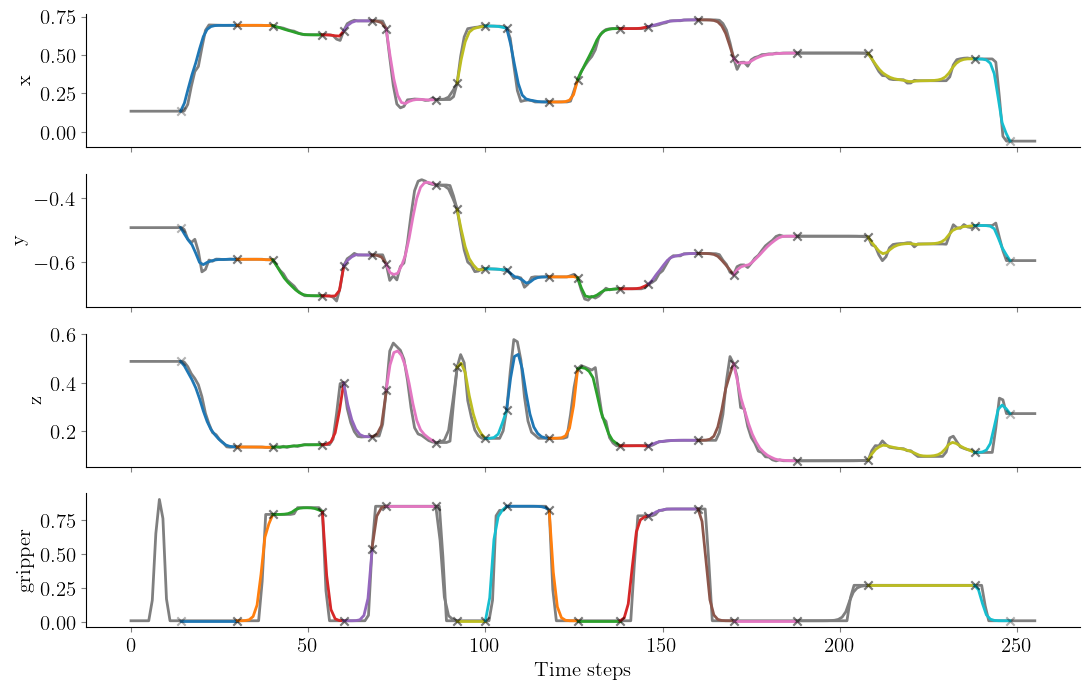

In [63]:
n_nodes_tmp = n_nodes
# with plt.style.context("ggplot_perso.mplstyle"):
fig, axes = plt.subplots(nrows=pos_segm.shape[1], ncols=1, sharex=True, figsize=(11, 7))
cmap = mpl.colormaps.get("Set3").colors
# plt_labels = traj.columns[colsids2keep]
plt_labels = [df_labels[item] for item in colsids2keep]
labels_fontsize = 15
ts = np.arange(stop=X_down_scaled.shape[0])
for axi, axv in enumerate(axes):
    for item in (
        [axv.title, axv.xaxis.label, axv.yaxis.label]
        + axv.get_xticklabels()
        + axv.get_yticklabels()
    ):
        item.set_fontsize(labels_fontsize)
    # axv.plot(X_down_scaled[:, axi], color="k", label="Data", alpha=0.5, lw=2)
    axv.plot(X_down.to_numpy()[:, axi], color="k", label="Data", alpha=0.5, lw=2)
    axv.set_ylabel(plt_labels[axi])
    axv.tick_params(color="gray")
    axv.spines[["right", "top"]].set_visible(False)

# chg_pts_all[-1] = chg_pts_all[-1] - 1
for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
    ## Number of ElMaps nodes can't be greater than the number of data points
    n_nodes = n_nodes_tmp
    num_pts_cur = abs(chg_pts_all[seg_i + 1] - chg_pts_all[seg_i])
    if num_pts_cur < n_nodes:
        n_nodes = num_pts_cur

    ts_segm_ref = np.linspace(
        start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=n_nodes
    )
    # pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], colsids2keep]
    pos_segm = X_down.to_numpy()[
        chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], colsids2keep
    ]
    # ts_elmap = np.arange(pos_segm.shape[0])[:, np.newaxis]
    ts_elmap = np.linspace(
        start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=pos_segm.shape[0]
    )[:, np.newaxis]
    traj_to_learn = np.concat((ts_elmap, pos_segm), axis=1)

    elmap = ElmapEM(
        [traj_to_learn],
        n=n_nodes,
        weighting=weighting,
        downsampling=downsampling,
        stretch=stretch,
        bend=bend,
    )
    # constraints = X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], colsids2keep]
    constraints = np.hstack(
        (
            np.array([ts_elmap[0], ts_elmap[-1]]),
            # X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], 0:3],
            # X_down_scaled[:, colsids2keep][
            #     [chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], :
            # ],
            X_down.to_numpy()[:, colsids2keep][
                [chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], :
            ],
        )
    )

    # # To be removed
    # if seg_i == 6:
    #     constraints[-1, 2] += 0.09
    # if seg_i == 7:
    #     constraints[0, 2] += 0.09

    with np.printoptions(precision=3, suppress=True):
        print(f"Constraints:\n{constraints}")
    new_traj = elmap.optimize_map(
        consts=constraints,
        inds=[0, n_nodes - 1],
    )
    new_traj_end = new_traj[:, 1:]
    with np.printoptions(precision=3, suppress=True):
        print(f"Start of learned trajectory: {new_traj[0]}")
        print(f"End of learned trajectory: {new_traj[-1]}")
    # new_traj_unscaled = minmaxscaler.inverse_transform(
    #     np.hstack((new_traj_end, np.zeros((new_traj_end.shape[0], nsegments))))
    # )[:, colsids2keep]
    np.savetxt(
        f"LfD_segm_{seg_i}.txt",
        # new_traj_unscaled,
        new_traj_end,
        delimiter=",",
        header=", ".join(list(plt_labels))
        + f"\n{[int(item) for item in true_chg_pts]}",
    )

    for axi, axv in enumerate(axes):
        axv.plot(
            ts_segm_ref,
            new_traj_end[:, axi],
            # color=cmap[seg_i],
            label=f"LfD {seg_i}",
            lw=2,
        )
        axv.scatter(
            ts_segm_ref[0],
            constraints[0, axi + 1],
            marker="x",
            color="k",
            alpha=0.3,
            zorder=2.5,
        )
        axv.scatter(
            ts_segm_ref[-1],
            constraints[-1, axi + 1],
            marker="x",
            color="k",
            alpha=0.3,
            zorder=2.5,
        )

axes[-1].set_xlabel("Time steps")
# axes[-1].legend(bbox_to_anchor=(1, -0.5), ncol=6, fontsize=labels_fontsize)
if TRANSP_BACK_PLOT:
    fig.patch.set_alpha(0)
    fig.patch.set_facecolor("white")
fig.tight_layout()

plt.show()